
# Testes de Sanidade e Vieses Algorítmicos do Metropolis

Material de apoio ao TCC: Comparação e Otimização de Algoritmos de Monte
Carlo Aplicados ao Modelo de Ising (Diego R. Oliveira, UFPR).

Este notebook implementa os dois testes de sanidade descritos na Seção
4.4.3 do TCC. A ideia dos dois testes é a mesma: introduzir de propósito
um erro clássico de implementação, comparar o resultado com a solução
exata de Onsager, e confirmar que o erro produz um desvio sistemático
claro. Isso valida, por contraste, que a implementação correta usada nas
simulações oficiais está livre desses dois problemas específicos.

As funções do algoritmo de Metropolis são redefinidas aqui, idênticas às
do notebook `metropolis.ipynb`, porque este notebook precisa criar
variantes propositalmente quebradas ao lado da versão correta, para
comparar as duas lado a lado na mesma execução.


In [1]:

import os
from google.colab import drive

drive.mount('/content/drive')

assert os.path.ismount('/content/drive'), (
    "ERRO. Google Drive nao esta montado. "
    "Nao prossiga ate resolver isso."
)
print("Drive confirmado como montado corretamente.")


Mounted at /content/drive
Drive confirmado como montado corretamente.


In [2]:

!git clone https://github.com/diegorafael1010/ising-monte-carlo.git


Cloning into 'ising-monte-carlo'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 38 (delta 17), reused 21 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 60.73 KiB | 1.17 MiB/s, done.
Resolving deltas: 100% (17/17), done.


In [3]:

import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/ising-monte-carlo')
from ising_utils import (
    inicializar_rede,
    construir_tabela_vizinhos,
    energia_total,
    magnetizacao_total,
    energia_onsager,
    magnetizacao_onsager,
    temperatura_critica_onsager,
    J,
)

SEED = 42
rng = np.random.default_rng(SEED)



## Funções base do Metropolis, versão correta

Estas funções reproduzem exatamente a implementação de
`metropolis.ipynb`, incluindo a versão em listas Python usada no laço
quente por motivo de desempenho. Servem de base tanto para a simulação de
referência quanto para as duas variantes quebradas construídas a seguir.


In [4]:

def delta_E_local(estado, vizinhos, k):
    n0, n1, n2, n3 = vizinhos[k]
    soma_vizinhos = estado[n0] + estado[n1] + estado[n2] + estado[n3]
    return 2.0 * J * estado[k] * soma_vizinhos


def construir_lookup_boltzmann(beta):
    return {dE: np.exp(-beta * dE) for dE in (4.0, 8.0)}


def tentativa_metropolis(estado, vizinhos, k, lookup, rng):
    dE = delta_E_local(estado, vizinhos, k)
    if dE <= 0:
        aceito = True
    else:
        aceito = rng.random() < lookup[dE]
    if aceito:
        estado[k] *= -1
    return aceito


def sweep_metropolis(estado, vizinhos, lookup, rng):
    N = len(estado)
    sitios = rng.integers(0, N, size=N)
    for k in sitios:
        tentativa_metropolis(estado, vizinhos, int(k), lookup, rng)


def preparar_simulacao(L, T, modo_inicial, rng):
    estado = inicializar_rede(L, modo=modo_inicial, rng=rng).tolist()
    vizinhos_np = construir_tabela_vizinhos(L)
    vizinhos = [tuple(int(x) for x in row) for row in vizinhos_np]
    lookup = construir_lookup_boltzmann(1.0 / T)
    return estado, vizinhos, vizinhos_np, lookup



## Primeiro teste: recontagem de estados rejeitados

O erro clássico descrito na Seção 4.4.3.1 do TCC consiste em acumular as
médias físicas apenas após uma tentativa de flip ser aceita, ignorando os
passos em que a tentativa foi rejeitada. Isso parece inofensivo à
primeira vista (afinal, a configuração não mudou mesmo), mas o efeito é
sutil. Quando a cadeia de Markov fica um tempo longo tentando sair de uma
configuração bem ordenada, a maioria das tentativas de flip é rejeitada,
e o sistema realmente passa a maior parte do tempo naquela configuração
específica. Ignorar os passos rejeitados equivale a ignorar justamente
esse tempo de permanência, o que faz o algoritmo amostrar as
configurações de baixa energia com peso menor do que deveria.

A previsão física é clara: a energia média calculada dessa forma deve
sair sistematicamente mais alta (ou seja, menos negativa) do que o valor
exato de Onsager, e o efeito deve ser mais forte em temperaturas baixas,
onde o sistema passa mais tempo parado em configurações ordenadas.

Vale notar também que a versão quebrada acumula muito menos amostras do
que a versão correta, para o mesmo número de tentativas de flip. Isso
acontece porque ela só registra uma medida quando a tentativa é aceita, e
em temperaturas baixas a grande maioria das tentativas é rejeitada. O
gráfico de convergência mais adiante usa escala logarítmica no eixo
horizontal justamente para deixar visível a convergência dos dois lados,
apesar dessa diferença grande na quantidade de amostras.


In [5]:

def simular_com_recontagem(L, T, n_eq, n_prod, rng):
    estado, vizinhos, vizinhos_np, lookup = preparar_simulacao(L, T, 'fria', rng)
    N = L * L

    for _ in range(n_eq):
        sweep_metropolis(estado, vizinhos, lookup, rng)

    energias = []
    total_tentativas = n_prod * N
    for _ in range(total_tentativas):
        k = int(rng.integers(0, N))
        tentativa_metropolis(estado, vizinhos, k, lookup, rng)
        estado_np = np.array(estado, dtype=np.int8)
        e = energia_total(estado_np, vizinhos_np) / N
        energias.append(e)

    return np.array(energias)


def simular_sem_recontagem(L, T, n_eq, n_prod, rng):
    estado, vizinhos, vizinhos_np, lookup = preparar_simulacao(L, T, 'fria', rng)
    N = L * L

    for _ in range(n_eq):
        sweep_metropolis(estado, vizinhos, lookup, rng)

    energias = []
    total_tentativas = n_prod * N
    for _ in range(total_tentativas):
        k = int(rng.integers(0, N))
        aceito = tentativa_metropolis(estado, vizinhos, k, lookup, rng)
        if aceito:
            estado_np = np.array(estado, dtype=np.int8)
            e = energia_total(estado_np, vizinhos_np) / N
            energias.append(e)

    return np.array(energias)


In [6]:

L_teste1 = 16
T_teste1 = 1.5
n_eq_teste1 = 1000
n_prod_teste1 = 2000

energia_exata = energia_onsager(T_teste1)

rng_a = np.random.default_rng(SEED)
energias_corretas = simular_com_recontagem(L_teste1, T_teste1, n_eq_teste1, n_prod_teste1, rng_a)

rng_b = np.random.default_rng(SEED)
energias_quebradas = simular_sem_recontagem(L_teste1, T_teste1, n_eq_teste1, n_prod_teste1, rng_b)

print(f"Energia exata de Onsager, T igual a {T_teste1}, {energia_exata:.5f}")
print(f"Energia media, implementacao correta, {energias_corretas.mean():.5f}")
print(f"Energia media, sem recontagem de rejeicoes, {energias_quebradas.mean():.5f}")
print(f"Numero de amostras aceitas na versao quebrada, {len(energias_quebradas)} de {n_prod_teste1 * L_teste1**2} tentativas totais")


Energia exata de Onsager, T igual a 1.5, -1.95112
Energia media, implementacao correta, -1.95143
Energia media, sem recontagem de rejeicoes, -1.92788
Numero de amostras aceitas na versao quebrada, 6880 de 512000 tentativas totais


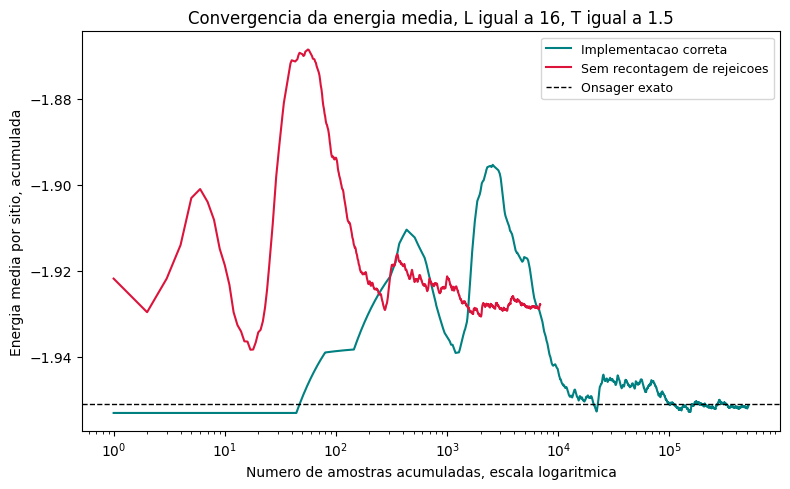

In [7]:

def media_cumulativa(serie):
    return np.cumsum(serie) / np.arange(1, len(serie) + 1)


fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, len(energias_corretas) + 1), media_cumulativa(energias_corretas),
        color='teal', label='Implementacao correta')
ax.plot(np.arange(1, len(energias_quebradas) + 1), media_cumulativa(energias_quebradas),
        color='crimson', label='Sem recontagem de rejeicoes')
ax.axhline(energia_exata, color='black', ls='--', lw=1, label='Onsager exato')
ax.set_xscale('log')
ax.set_xlabel('Numero de amostras acumuladas, escala logaritmica')
ax.set_ylabel('Energia media por sitio, acumulada')
ax.set_title(f'Convergencia da energia media, L igual a {L_teste1}, T igual a {T_teste1}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('vies_recontagem_rejeicoes.png', dpi=150)
plt.show()



## Segundo teste: quebra de balanço detalhado

O segundo erro, descrito na Seção 4.4.3.2 do TCC, quebra a simetria de
seleção exigida pelo balanço detalhado. Vale um comentário sobre como
implementar isso de forma que o erro realmente aconteça. Se a
probabilidade de escolher um sítio depender apenas do índice dele, sem
depender do valor do spin naquele momento, a seleção continua simétrica
na prática, porque ir de uma configuração para outra e o caminho inverso
usam exatamente a mesma probabilidade de escolher aquele mesmo índice. A
simetria só quebra de verdade quando a probabilidade de escolher um sítio
depende do próprio valor do spin ali, porque nesse caso o caminho de ida
e o caminho de volta passam a ter probabilidades de seleção diferentes.

A versão quebrada implementada abaixo sorteia primeiro um valor-alvo de
spin, mais um com probabilidade alta, e só então escolhe aleatoriamente
um sítio entre os que têm esse valor no momento. Isso favorece
tentativas de inversão nos sítios que ainda estão no valor mais
frequentemente sorteado, sem nenhum fator de correção na probabilidade de
aceitação. A previsão física é que o sistema seja empurrado para uma
polarização artificial, bem distante do valor real de magnetização.

O teste é feito numa temperatura acima de Tc, onde a magnetização real,
no limite de rede infinita, é zero. Para uma rede finita como a usada
aqui, a implementação correta ainda deve mostrar um resíduo pequeno de
magnetização, o mesmo efeito de tamanho finito já discutido em outros
notebooks deste projeto, bem diferente da polarização quase total que a
versão quebrada deve produzir.



In [8]:

def sweep_balanco_quebrado(estado, vizinhos, lookup, rng, vies):
    N = len(estado)
    for _ in range(N):
        alvo = 1 if rng.random() < vies else -1
        candidatos = [i for i in range(N) if estado[i] == alvo]
        if not candidatos:
            continue
        k = candidatos[int(rng.integers(0, len(candidatos)))]
        tentativa_metropolis(estado, vizinhos, k, lookup, rng)


def simular_balanco_correto(L, T, n_eq, n_prod, rng):
    estado, vizinhos, vizinhos_np, lookup = preparar_simulacao(L, T, 'quente', rng)
    for _ in range(n_eq):
        sweep_metropolis(estado, vizinhos, lookup, rng)

    magnetizacoes = []
    for _ in range(n_prod):
        sweep_metropolis(estado, vizinhos, lookup, rng)
        estado_np = np.array(estado, dtype=np.int8)
        m = abs(magnetizacao_total(estado_np)) / (L * L)
        magnetizacoes.append(m)
    return np.array(magnetizacoes)


def simular_balanco_quebrado(L, T, n_eq, n_prod, rng, vies=0.85):
    estado, vizinhos, vizinhos_np, lookup = preparar_simulacao(L, T, 'quente', rng)
    for _ in range(n_eq):
        sweep_balanco_quebrado(estado, vizinhos, lookup, rng, vies)

    magnetizacoes = []
    for _ in range(n_prod):
        sweep_balanco_quebrado(estado, vizinhos, lookup, rng, vies)
        estado_np = np.array(estado, dtype=np.int8)
        m = abs(magnetizacao_total(estado_np)) / (L * L)
        magnetizacoes.append(m)
    return np.array(magnetizacoes)


In [9]:

L_teste2 = 16
T_teste2 = 2.5
n_eq_teste2 = 200
n_prod_teste2 = 400

magnetizacao_exata = magnetizacao_onsager(T_teste2)

rng_c = np.random.default_rng(SEED)
magnetizacoes_corretas = simular_balanco_correto(L_teste2, T_teste2, n_eq_teste2, n_prod_teste2, rng_c)

rng_d = np.random.default_rng(SEED)
magnetizacoes_quebradas = simular_balanco_quebrado(L_teste2, T_teste2, n_eq_teste2, n_prod_teste2, rng_d)

print(f"Magnetizacao exata de Onsager, T igual a {T_teste2:.3f}, {magnetizacao_exata:.5f}")
print(f"Magnetizacao media, implementacao correta, {magnetizacoes_corretas.mean():.5f}")
print(f"Magnetizacao media, balanco detalhado quebrado, {magnetizacoes_quebradas.mean():.5f}")


Magnetizacao exata de Onsager, T igual a 2.500, 0.00000
Magnetizacao media, implementacao correta, 0.30896
Magnetizacao media, balanco detalhado quebrado, 0.99994


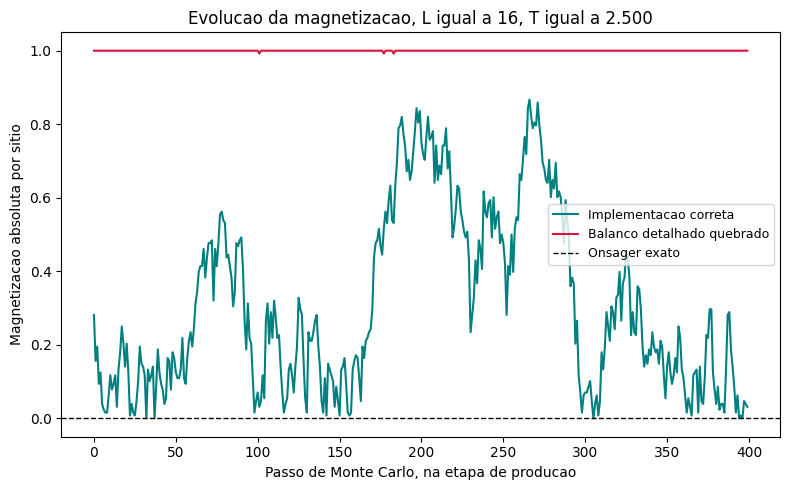

In [10]:

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(magnetizacoes_corretas, color='teal', label='Implementacao correta')
ax.plot(magnetizacoes_quebradas, color='crimson', label='Balanco detalhado quebrado')
ax.axhline(magnetizacao_exata, color='black', ls='--', lw=1, label='Onsager exato')
ax.set_xlabel('Passo de Monte Carlo, na etapa de producao')
ax.set_ylabel('Magnetizacao absoluta por sitio')
ax.set_title(f'Evolucao da magnetizacao, L igual a {L_teste2}, T igual a {T_teste2:.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('vies_balanco_detalhado.png', dpi=150)
plt.show()



## Resumo dos dois testes

Os dois testes confirmam o comportamento previsto na Secao 4.4.3 do TCC.
A implementacao correta acompanha de perto o valor exato de Onsager nos
dois casos, enquanto as duas variantes deliberadamente quebradas se
afastam de forma clara e sistematica, nao apenas por flutuacao
estatistica. Isso da suporte empirico a conclusao de que a implementacao
usada nas simulacoes oficiais, que compartilha as mesmas funcoes base
validadas aqui, esta livre desses dois vieses especificos.
